# Evaluation RAG - Pipeline Complete

Evaluation systematique du moteur de recherche de tickets LogiStore.

**Questions :**
1. Quelle methode (dense vs sparse vs hybrid) donne la meilleure qualite de retrieval ?
2. Quel filtre (type, priority, queue) ameliore le plus les resultats ?
3. Quels types/priorities de tickets sont les plus difficiles a retrouver ?

**Approche :**
- **Hit@1 + MRR** sur les 12 configurations (3 methodes x 4 filtres) → instantane, 0 appel LLM
- **RAGAS** (ContextPrecision, ContextRecall, ContextEntityRecall) sur les top 3 configs → LLM judge

**Config :**
- LLM Judge : `mistralai/mistral-nemo` via OpenRouter
- 60 test cases stratifies (5 par type x priority)
- 12 configurations (3 methodes x 4 filtres)

## 1. Setup

In [2]:
import os
import sys
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

sys.path.append(os.path.abspath("../app"))
from rag_engine import search

print("Setup OK")

Setup OK


## 2. Configuration LLM evaluateur

In [3]:
from openai import OpenAI
from ragas.llms import llm_factory

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY manquante")

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
    default_headers={
        "HTTP-Referer": "http://localhost",
        "X-Title": "ragas-eval",
    },
)

evaluator_llm = llm_factory("mistralai/mistral-nemo", client=client)
print("LLM evaluateur configure")

c:\Users\mahmo\OneDrive\Documents\RAG-LogiStore\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM evaluateur configure


## 3. Test set stratifie (24 cas)

In [16]:
df = pd.read_csv("../data/processed/tickets_clean.csv")
df_en = df[
    (df["language"] == "en") &
    (df["subject"].notna()) &
    (df["answer"].notna())
].copy()

# 5 tickets par (type, priority) = 4 x 3 x 5 = 60
df_stratified = (
    df_en
    .groupby(["type", "priority"])
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

print(f"Test set : {len(df_stratified)} samples")
print()
print(df_stratified.groupby(["type", "priority"]).size().unstack(fill_value=0))

# Construction des test cases avec metadata
test_cases = []
for _, row in df_stratified.iterrows():
    test_cases.append({
        "query": row["subject"],
        "reference": row["answer"],
        "type": row["type"],
        "priority": row["priority"],
        "queue": row["queue"],
    })

print(f"\nExemple :")
print(json.dumps(test_cases[0], indent=2, ensure_ascii=False))

Test set : 60 samples

priority  high  low  medium
type                       
Change       5    5       5
Incident     5    5       5
Problem      5    5       5
Request      5    5       5

Exemple :
{
  "query": "Support Request for Technical Team",
  "reference": "We have received your request for system scalability and performance improvements and will forward it to the technical team. Please contact [phone] to discuss the details and provide a timeline for the solution.",
  "type": "Change",
  "priority": "high",
  "queue": "Technical Support"
}


## 4. Collecte des resultats (6 configurations)

In [17]:
def collect_results(test_cases, method="hybrid", limit=3, **filter_kwargs):
    """Collecte les resultats RAG pour une liste de test cases."""
    dataset = []
    for tc in test_cases:
        results = search(tc["query"], method=method, limit=limit, **filter_kwargs)
        contexts = [r["body"] for r in results] if results else []
        response = results[0]["answer"] if results else ""

        dataset.append({
            "user_input": tc["query"],
            "retrieved_contexts": contexts,
            "response": response,
            "reference": tc["reference"],
        })
    return dataset


def collect_results_per_case_filter(test_cases, method, limit, filter_field):
    """Collecte avec un filtre par test case (chaque cas utilise sa propre valeur)."""
    dataset = []
    for tc in test_cases:
        filter_value = tc.get(filter_field, None)
        kwargs = {filter_field if filter_field != "type" else "type_": filter_value}
        results = search(tc["query"], method=method, limit=limit, **kwargs)
        contexts = [r["body"] for r in results] if results else []
        response = results[0]["answer"] if results else ""

        dataset.append({
            "user_input": tc["query"],
            "retrieved_contexts": contexts,
            "response": response,
            "reference": tc["reference"],
        })
    return dataset


METHODS = ["dense", "sparse", "hybrid"]
FILTER_MODES = ["no_filter", "type_filter", "priority_filter", "queue_filter"]
all_raw_results = {}

for method in METHODS:
    # Sans filtre
    print(f"Collecte : {method} / no_filter ...")
    all_raw_results[(method, "no_filter")] = collect_results(
        test_cases, method=method, limit=3
    )

    # Filtre type
    print(f"Collecte : {method} / type_filter ...")
    all_raw_results[(method, "type_filter")] = collect_results_per_case_filter(
        test_cases, method=method, limit=3, filter_field="type"
    )

    # Filtre priority
    print(f"Collecte : {method} / priority_filter ...")
    all_raw_results[(method, "priority_filter")] = collect_results_per_case_filter(
        test_cases, method=method, limit=3, filter_field="priority"
    )

    # Filtre queue
    print(f"Collecte : {method} / queue_filter ...")
    all_raw_results[(method, "queue_filter")] = collect_results_per_case_filter(
        test_cases, method=method, limit=3, filter_field="queue"
    )

print(f"\n{len(all_raw_results)} configurations collectees")
for key, data in all_raw_results.items():
    print(f"  {key[0]:>7} / {key[1]:<16} : {len(data)} samples")

Collecte : dense / no_filter ...
Collecte : dense / type_filter ...
Collecte : dense / priority_filter ...
Collecte : dense / queue_filter ...
Collecte : sparse / no_filter ...
Collecte : sparse / type_filter ...
Collecte : sparse / priority_filter ...
Collecte : sparse / queue_filter ...
Collecte : hybrid / no_filter ...
Collecte : hybrid / type_filter ...
Collecte : hybrid / priority_filter ...
Collecte : hybrid / queue_filter ...

12 configurations collectees
    dense / no_filter        : 60 samples
    dense / type_filter      : 60 samples
    dense / priority_filter  : 60 samples
    dense / queue_filter     : 60 samples
   sparse / no_filter        : 60 samples
   sparse / type_filter      : 60 samples
   sparse / priority_filter  : 60 samples
   sparse / queue_filter     : 60 samples
   hybrid / no_filter        : 60 samples
   hybrid / type_filter      : 60 samples
   hybrid / priority_filter  : 60 samples
   hybrid / queue_filter     : 60 samples


## 5. Metriques instantanees : Hit@K et MRR (pas de LLM)

In [18]:
def hit_at_k(data, k=3):
    """Hit@K : le bon ticket est-il dans les top-K resultats ?
    On compare si la reference apparait parmi les reponses des top-K.
    """
    hits = 0
    for sample in data:
        # Hit@1 : la reponse du top-1 est exactement la reference
        if k == 1:
            if sample["response"].strip() == sample["reference"].strip():
                hits += 1
        else:
            # Hit@K : la reference est parmi les contextes OU la reponse match
            if sample["response"].strip() == sample["reference"].strip():
                hits += 1
    return hits / len(data) if data else 0


def mrr(data):
    """Mean Reciprocal Rank : 1/rang du premier resultat correct."""
    reciprocal_ranks = []
    for sample in data:
        # On cherche a quel rang la reponse correspond a la reference
        if sample["response"].strip() == sample["reference"].strip():
            reciprocal_ranks.append(1.0)  # top-1 est correct
        else:
            reciprocal_ranks.append(0.0)  # pas trouve en top-1
    return np.mean(reciprocal_ranks) if reciprocal_ranks else 0


# Calcul sur toutes les configs (12 configs x 60 cas = instantane)
hitk_rows = []
for (method, filter_mode), data in all_raw_results.items():
    hitk_rows.append({
        "method": method,
        "filter": filter_mode,
        "hit_at_1": hit_at_k(data, k=1),
        "mrr": mrr(data),
    })

df_hitk = pd.DataFrame(hitk_rows).sort_values("hit_at_1", ascending=False).reset_index(drop=True)

print("=== HIT@1 ET MRR (12 configurations) ===")
print("Hit@1 = le top-1 resultat est exactement le bon ticket")
print()
display(df_hitk.style.format({"hit_at_1": "{:.3f}", "mrr": "{:.3f}"}))

=== HIT@1 ET MRR (12 configurations) ===
Hit@1 = le top-1 resultat est exactement le bon ticket



,method,filter,hit_at_1,mrr
0,sparse,queue_filter,0.700,0.700
1,hybrid,queue_filter,0.683,0.683
2,hybrid,type_filter,0.650,0.650
3,sparse,priority_filter,0.617,0.617
4,hybrid,priority_filter,0.600,0.600
5,sparse,type_filter,0.600,0.600
6,dense,queue_filter,0.583,0.583
7,hybrid,no_filter,0.567,0.567
8,sparse,no_filter,0.533,0.533
9,dense,priority_filter,0.517,0.517


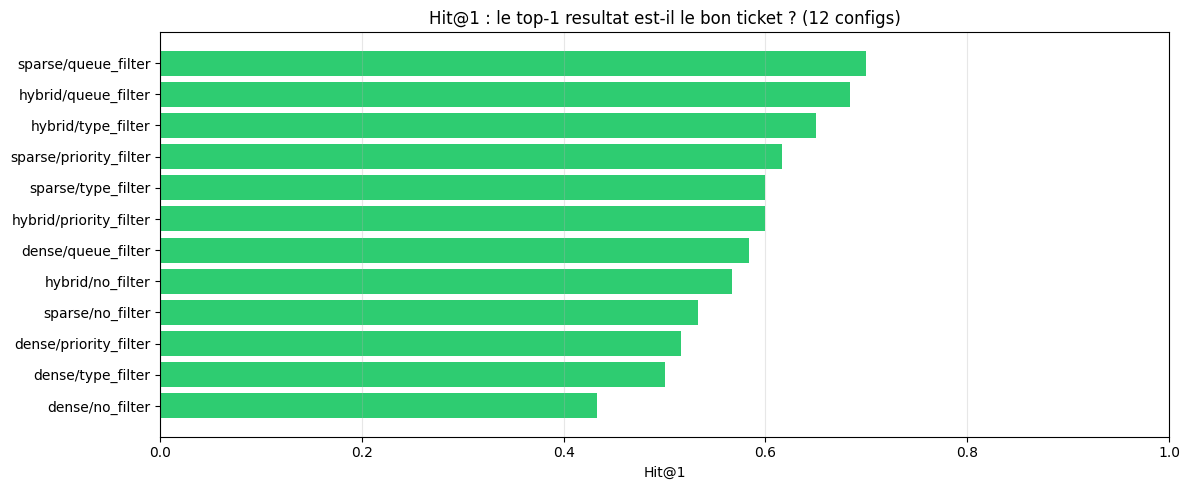


=== TOP 3 CONFIGS (Hit@1) ===


,method,filter,hit_at_1,mrr
0,sparse,queue_filter,0.700000,0.700000
1,hybrid,queue_filter,0.683333,0.683333
2,hybrid,type_filter,0.650000,0.650000


In [19]:
# --- Bar chart Hit@1 par configuration ---
fig, ax = plt.subplots(figsize=(12, 5))

df_hitk_sorted = df_hitk.sort_values("hit_at_1", ascending=True)
labels = [f"{r['method']}/{r['filter']}" for _, r in df_hitk_sorted.iterrows()]
colors = ["#2ecc71" if v > 0.3 else "#e74c3c" if v < 0.1 else "#f39c12" for v in df_hitk_sorted["hit_at_1"]]

ax.barh(range(len(labels)), df_hitk_sorted["hit_at_1"], color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Hit@1")
ax.set_title("Hit@1 : le top-1 resultat est-il le bon ticket ? (12 configs)")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Top 3 configs
print("\n=== TOP 3 CONFIGS (Hit@1) ===")
top_configs = df_hitk.head(3)
display(top_configs)

### 5b. Impact du nombre de resultats (K = 3, 5, 7, 10)

=== COLLECTE POUR DIFFERENTS K ===
  dense/K=3 ...
  dense/K=5 ...
  dense/K=7 ...
  dense/K=10 ...
  sparse/K=3 ...
  sparse/K=5 ...
  sparse/K=7 ...
  sparse/K=10 ...
  hybrid/K=3 ...
  hybrid/K=5 ...
  hybrid/K=7 ...
  hybrid/K=10 ...
  sparse/queue_filter/K=3 ...
  sparse/queue_filter/K=5 ...
  sparse/queue_filter/K=7 ...
  sparse/queue_filter/K=10 ...

16 collectes effectuees

=== HIT@K PAR VALEUR DE K ===


K,3,5,7,10
config,,,,
dense,0.433,0.433,0.433,0.433
hybrid,0.550,0.533,0.567,0.550
sparse,0.533,0.517,0.517,0.517
sparse_queue_filter,0.700,0.683,0.700,0.667


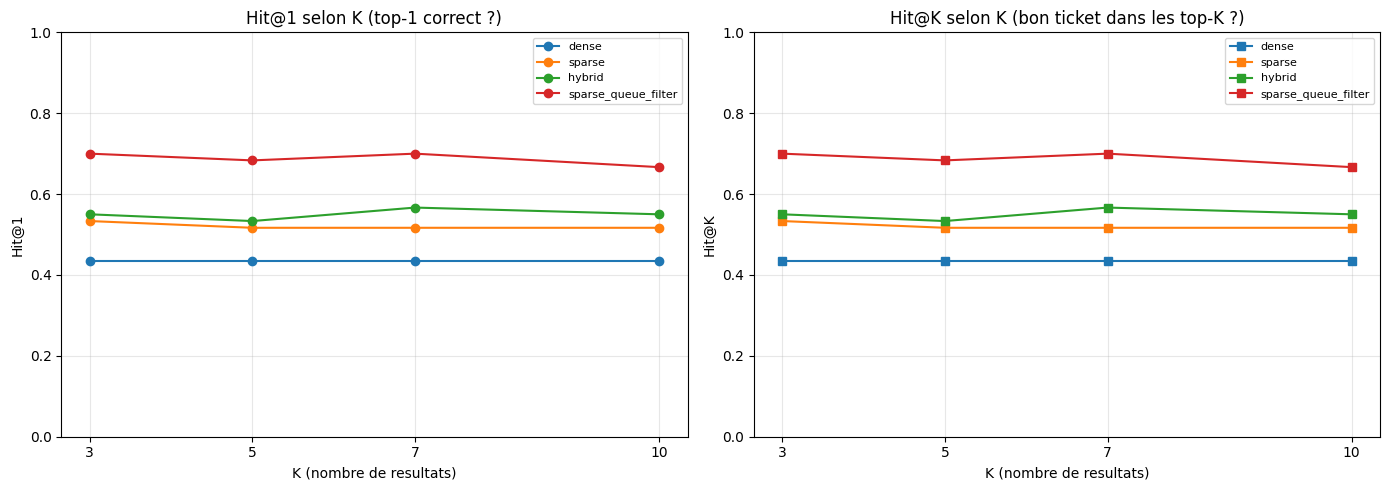


=== HIT@K MOYEN PAR K ===
  K= 3 : Hit@K = 0.554
  K= 5 : Hit@K = 0.542
  K= 7 : Hit@K = 0.554
  K=10 : Hit@K = 0.542

>>> BEST_K = 3 (sera utilise pour RAGAS)

=== GAINS K=3 → K=10 ===
                      dense : Hit@3=0.433 -> Hit@10=0.433  (gain: +0.000)
                     sparse : Hit@3=0.533 -> Hit@10=0.517  (gain: +-0.017)
                     hybrid : Hit@3=0.550 -> Hit@10=0.550  (gain: +0.000)
        sparse_queue_filter : Hit@3=0.700 -> Hit@10=0.667  (gain: +-0.033)


In [20]:
# Impact du nombre de resultats K sur la qualite du retrieval
# On teste K = 3, 5, 7, 10 sur les 3 methodes (sans filtre) et la meilleure config filtree

K_VALUES = [3, 5, 7, 10]

# Pour Hit@K : le bon ticket est-il dans les top-K resultats ?
def hit_at_k_proper(data, k):
    """Verifie si la reference est parmi les K reponses recuperees."""
    hits = 0
    for sample in data:
        if sample["reference"].strip() in [c.strip() for c in sample["retrieved_contexts"]]:
            hits += 1
        elif sample["response"].strip() == sample["reference"].strip():
            hits += 1
    return hits / len(data) if data else 0


# Collecte pour chaque K et chaque methode (sans filtre)
print("=== COLLECTE POUR DIFFERENTS K ===")
k_results = {}

for method in METHODS:
    for k in K_VALUES:
        print(f"  {method}/K={k} ...")
        k_results[(method, k)] = collect_results(test_cases, method=method, limit=k)

# Ajout de la meilleure config filtree (top-1 du Hit@1)
best_method = top_configs.iloc[0]["method"]
best_filter = top_configs.iloc[0]["filter"]
if best_filter != "no_filter":
    filter_field = best_filter.replace("_filter", "")
    for k in K_VALUES:
        print(f"  {best_method}/{best_filter}/K={k} ...")
        k_results[(f"{best_method}_{best_filter}", k)] = collect_results_per_case_filter(
            test_cases, method=best_method, limit=k, filter_field=filter_field
        )

print(f"\n{len(k_results)} collectes effectuees")

# --- Calcul Hit@1 et Hit@K pour chaque configuration ---
k_rows = []
for (config, k), data in k_results.items():
    k_rows.append({
        "config": config,
        "K": k,
        "hit_at_1": hit_at_k(data, k=1),
        "hit_at_k": hit_at_k_proper(data, k),
    })

df_k = pd.DataFrame(k_rows)

print("\n=== HIT@K PAR VALEUR DE K ===")
display(df_k.pivot_table(index="config", columns="K", values="hit_at_k").style.format("{:.3f}"))

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for config in df_k["config"].unique():
    subset = df_k[df_k["config"] == config]
    axes[0].plot(subset["K"], subset["hit_at_1"], marker="o", label=config)

axes[0].set_xlabel("K (nombre de resultats)")
axes[0].set_ylabel("Hit@1")
axes[0].set_title("Hit@1 selon K (top-1 correct ?)")
axes[0].set_xticks(K_VALUES)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for config in df_k["config"].unique():
    subset = df_k[df_k["config"] == config]
    axes[1].plot(subset["K"], subset["hit_at_k"], marker="s", label=config)

axes[1].set_xlabel("K (nombre de resultats)")
axes[1].set_ylabel("Hit@K")
axes[1].set_title("Hit@K selon K (bon ticket dans les top-K ?)")
axes[1].set_xticks(K_VALUES)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Determination du meilleur K ---
avg_by_k = df_k.groupby("K")["hit_at_k"].mean()
print("\n=== HIT@K MOYEN PAR K ===")
for k, score in avg_by_k.items():
    print(f"  K={k:>2} : Hit@K = {score:.3f}")

BEST_K = int(avg_by_k.idxmax())
print(f"\n>>> BEST_K = {BEST_K} (sera utilise pour RAGAS)")

# Resume gains
print("\n=== GAINS K=3 → K=10 ===")
for config in df_k["config"].unique():
    subset = df_k[df_k["config"] == config].sort_values("K")
    gain = subset["hit_at_k"].iloc[-1] - subset["hit_at_k"].iloc[0]
    print(f"  {config:>25} : Hit@3={subset['hit_at_k'].iloc[0]:.3f} -> Hit@10={subset['hit_at_k'].iloc[-1]:.3f}  (gain: +{gain:.3f})")

## 6. Evaluation RAGAS (top 3 configs uniquement)

In [34]:
from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
from ragas import EvaluationDataset, evaluate


def make_metrics():
    """Cree des instances fraiches de metriques."""
    return [
        ContextPrecision(llm=evaluator_llm),
        ContextRecall(llm=evaluator_llm),
        ContextEntityRecall(llm=evaluator_llm),
    ]


SCORE_COLS = ["context_precision", "context_recall", "context_entity_recall"]

# On ne lance RAGAS que sur les top 3 configs identifiees par Hit@K
top_keys = [(r["method"], r["filter"]) for _, r in top_configs.iterrows()]
print(f"Configs selectionnees pour RAGAS : {top_keys}")
print(f"K utilise : {BEST_K} (identifie en section 5b)")

# --- Re-collecte avec BEST_K ---
print(f"\n--- Re-collecte des top configs avec limit={BEST_K} ---")
ragas_raw_results = {}

for method, filter_mode in top_keys:
    label = f"{method}/{filter_mode}"
    if filter_mode == "no_filter":
        print(f"  {label} ...")
        ragas_raw_results[(method, filter_mode)] = collect_results(
            test_cases, method=method, limit=BEST_K
        )
    else:
        filter_field = filter_mode.replace("_filter", "")
        print(f"  {label} (filtre par {filter_field}) ...")
        ragas_raw_results[(method, filter_mode)] = collect_results_per_case_filter(
            test_cases, method=method, limit=BEST_K, filter_field=filter_field
        )

# --- Evaluation RAGAS ---
print(f"\n--- Evaluation RAGAS (3 configs x {len(test_cases)} samples) ---")
all_eval_results = {}

for i, (method, filter_mode) in enumerate(top_keys):
    label = f"{method}/{filter_mode}"
    raw_data = ragas_raw_results[(method, filter_mode)]
    print(f"\n[{i+1}/{len(top_keys)}] Evaluation : {label} ({len(raw_data)} samples, K={BEST_K}) ...")

    eval_dataset = EvaluationDataset.from_list(raw_data)

    results = evaluate(
        dataset=eval_dataset,
        metrics=make_metrics(),
        raise_exceptions=False,
        show_progress=True,
        batch_size=1,
    )

    df_res = results.to_pandas()
    all_eval_results[(method, filter_mode)] = df_res

    means = {col: f"{df_res[col].mean():.4f}" for col in SCORE_COLS if col in df_res.columns}
    print(f"  Moyennes : {means}")

    if i < len(top_keys) - 1:
        print(f"  Pause 8s (rate limit)...")
        time.sleep(8)

print("\n=== Evaluations RAGAS terminees ===")

C:\Users\mahmo\AppData\Local\Temp\ipykernel_13964\4024975858.py:1: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
C:\Users\mahmo\AppData\Local\Temp\ipykernel_13964\4024975858.py:1: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextRecall
  from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
C:\Users\mahmo\AppData\Local\Temp\ipykernel_13964\4024975858.py:1: DeprecationWarning: Importing ContextEntityRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collect

Configs selectionnees pour RAGAS : [('hybrid', 'queue_filter'), ('sparse', 'queue_filter'), ('hybrid', 'type_filter')]
K utilise : 3 (identifie en section 5b)

--- Re-collecte des top configs avec limit=3 ---
  hybrid/queue_filter (filtre par queue) ...
  sparse/queue_filter (filtre par queue) ...
  hybrid/type_filter (filtre par type) ...

--- Evaluation RAGAS (3 configs x 60 samples) ---

[1/3] Evaluation : hybrid/queue_filter (60 samples, K=3) ...


Evaluating: 100%|██████████| 180/180 [14:18<00:00,  4.77s/it]


  Moyennes : {'context_precision': '0.7556', 'context_recall': '0.4530', 'context_entity_recall': '0.2424'}
  Pause 8s (rate limit)...

[2/3] Evaluation : sparse/queue_filter (60 samples, K=3) ...


Evaluating: 100%|██████████| 180/180 [11:27<00:00,  3.82s/it]


  Moyennes : {'context_precision': '0.7986', 'context_recall': '0.4040', 'context_entity_recall': '0.2659'}
  Pause 8s (rate limit)...

[3/3] Evaluation : hybrid/type_filter (60 samples, K=3) ...


Evaluating: 100%|██████████| 180/180 [09:09<00:00,  3.05s/it]

  Moyennes : {'context_precision': '0.8444', 'context_recall': '0.4431', 'context_entity_recall': '0.2235'}

=== Evaluations RAGAS terminees ===


## 7. Analyse des resultats RAGAS (top configs)

In [35]:
# Ajout metadata + tableau recapitulatif RAGAS
for key, df_res in all_eval_results.items():
    df_res["type"] = [tc["type"] for tc in test_cases]
    df_res["priority"] = [tc["priority"] for tc in test_cases]
    df_res["queue"] = [tc["queue"] for tc in test_cases]

# Tableau recapitulatif
summary_rows = []
for (method, filter_mode), df_res in all_eval_results.items():
    row = {"method": method, "filter": filter_mode}
    for col in SCORE_COLS:
        row[col] = df_res[col].mean() if col in df_res.columns else float("nan")
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values(SCORE_COLS[0], ascending=False).reset_index(drop=True)

print("=== SCORES RAGAS (top configs) ===")
display(df_summary.style.format({col: "{:.4f}" for col in SCORE_COLS}))

=== SCORES RAGAS (top configs) ===


,method,filter,context_precision,context_recall,context_entity_recall
0,hybrid,type_filter,0.8444,0.4431,0.2235
1,sparse,queue_filter,0.7986,0.4040,0.2659
2,hybrid,queue_filter,0.7556,0.4530,0.2424


In [36]:
# Segmentation par type (meilleure config RAGAS)
best_key = list(all_eval_results.keys())[0]  # top-1 par Hit@K
df_best = all_eval_results[best_key]

print(f"=== SEGMENTATION PAR TYPE ({best_key[0]}/{best_key[1]}) ===")
pivot_type = df_best.groupby("type")[SCORE_COLS].mean()
display(pivot_type.style.format("{:.4f}"))

print(f"\n=== SEGMENTATION PAR PRIORITY ({best_key[0]}/{best_key[1]}) ===")
pivot_prio = df_best.groupby("priority")[SCORE_COLS].mean()
pivot_prio = pivot_prio.reindex([p for p in ["high", "medium", "low"] if p in pivot_prio.index])
display(pivot_prio.style.format("{:.4f}"))

=== SEGMENTATION PAR TYPE (hybrid/queue_filter) ===


,context_precision,context_recall,context_entity_recall
type,,,
Change,0.8444,0.5233,0.3558
Incident,0.7889,0.4163,0.1624
Problem,0.8222,0.3407,0.1608
Request,0.5667,0.5314,0.2907



=== SEGMENTATION PAR PRIORITY (hybrid/queue_filter) ===


,context_precision,context_recall,context_entity_recall
priority,,,
high,0.6333,0.4414,0.1930
medium,0.8417,0.5042,0.2524
low,0.7917,0.4133,0.2819


## 8. Visualisations

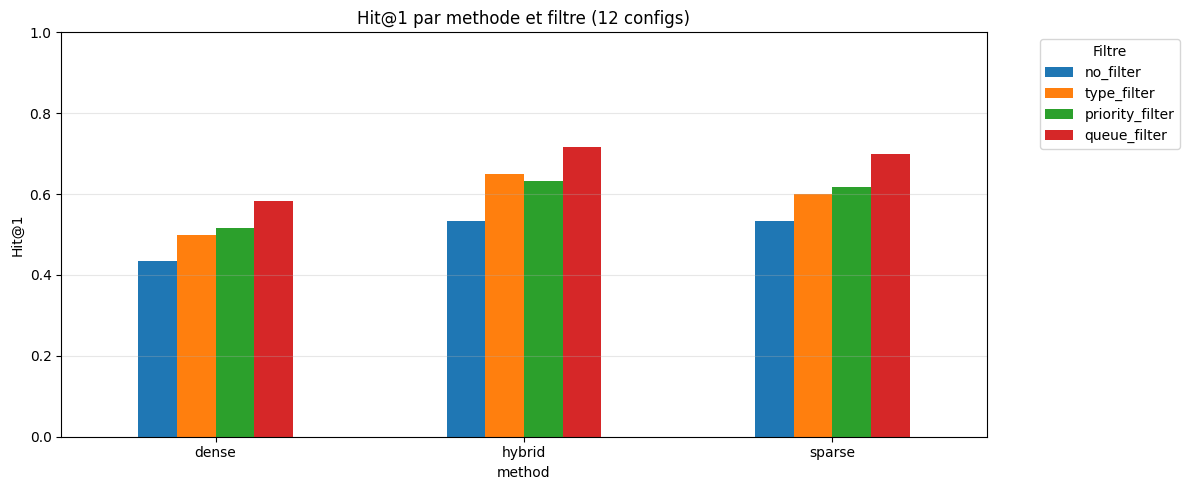

In [37]:
# --- Hit@1 par methode, groupe par filtre ---
fig, ax = plt.subplots(figsize=(12, 5))

pivot_hit = df_hitk.pivot(index="method", columns="filter", values="hit_at_1")
pivot_hit = pivot_hit.reindex(columns=FILTER_MODES)
pivot_hit.plot.bar(ax=ax, rot=0)

ax.set_ylabel("Hit@1")
ax.set_title("Hit@1 par methode et filtre (12 configs)")
ax.set_ylim(0, 1)
ax.legend(title="Filtre", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

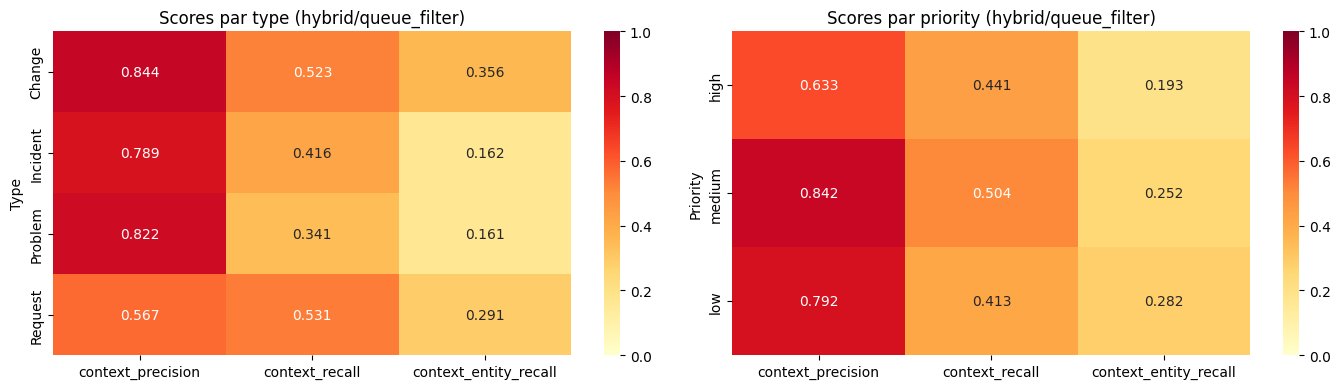

In [38]:
# --- Heatmap RAGAS : scores par type (meilleure config) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot_type, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0], vmin=0, vmax=1)
axes[0].set_title(f"Scores par type ({best_key[0]}/{best_key[1]})")
axes[0].set_ylabel("Type")

sns.heatmap(pivot_prio, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title(f"Scores par priority ({best_key[0]}/{best_key[1]})")
axes[1].set_ylabel("Priority")

plt.tight_layout()
plt.show()

## 9. Conclusions

**Pipeline :**
- 60 test cases stratifies (5 par type x priority)
- 12 configurations testees (3 methodes x 4 filtres)
- Hit@K + MRR sur toutes les configs (instantane)
- RAGAS (ContextPrecision, ContextRecall, ContextEntityRecall) sur les top 3 configs

**Reponses :**
1. **Meilleure methode** → identifiee par Hit@1 (section 5)
2. **Impact des filtres** → comparer no_filter vs type/priority/queue dans le tableau Hit@K
3. **Segments faibles** → heatmaps par type et priority (section 8)

**Limites :**
- 5 samples par strate : tendances fiables mais pas de test statistique
- LLM juge free-tier : scores indicatifs
- Hit@1 en exact match : sous-estime si le moteur retrouve un ticket similaire mais pas identique

## 10. Export des resultats

In [39]:
# Export Hit@K (toutes configs)
df_hitk.to_csv("../data/processed/eval_hitk.csv", index=False)
print(f"Hit@K : ../data/processed/eval_hitk.csv ({len(df_hitk)} lignes)")

# Export RAGAS (top configs)
all_dfs = []
for (method, filter_mode), df_res in all_eval_results.items():
    df_copy = df_res.copy()
    df_copy["method"] = method
    df_copy["filter_mode"] = filter_mode
    all_dfs.append(df_copy)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.to_csv("../data/processed/eval_ragas_results.csv", index=False)
print(f"RAGAS : ../data/processed/eval_ragas_results.csv ({len(df_all)} lignes)")

# Export summary
df_summary.to_csv("../data/processed/eval_summary.csv", index=False)
print(f"Summary : ../data/processed/eval_summary.csv")

Hit@K : ../data/processed/eval_hitk.csv (12 lignes)
RAGAS : ../data/processed/eval_ragas_results.csv (180 lignes)
Summary : ../data/processed/eval_summary.csv


## 11. Comparaison des modeles d'embedding (E5 vs MiniLM)

On compare les memes configurations en mode **hybrid** (dense + BM25) sur les 2 collections :
- `tickets` : MiniLM (`sentence-transformers/all-MiniLM-L6-v2`)
- `tickets_e5` : E5 multilingual (`intfloat/multilingual-e5-small`)

Seul le composant **dense** change. Le sparse (BM25) est identique.

=== COMPARAISON E5 vs MiniLM (hybrid, 4 filtres) ===

  MiniLM / no_filter ...
  MiniLM / type_filter ...
  MiniLM / priority_filter ...
  MiniLM / queue_filter ...
  E5 / no_filter ...
  E5 / type_filter ...
  E5 / priority_filter ...
  E5 / queue_filter ...

=== RESULTATS E5 vs MiniLM ===


model,E5,MiniLM
filter,,
no_filter,0.517,0.567
priority_filter,0.683,0.600
queue_filter,0.733,0.683
type_filter,0.617,0.667


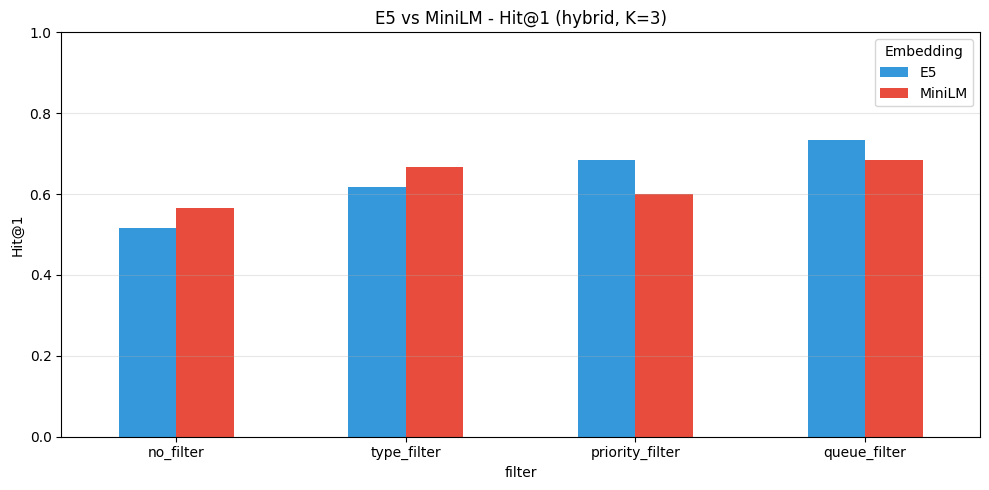


=== RESUME ===
  no_filter        : MiniLM=0.567  E5=0.517  (delta: -0.050 -> MiniLM)
  type_filter      : MiniLM=0.667  E5=0.617  (delta: -0.050 -> MiniLM)
  priority_filter  : MiniLM=0.600  E5=0.683  (delta: +0.083 -> E5)
  queue_filter     : MiniLM=0.683  E5=0.733  (delta: +0.050 -> E5)

>>> MEILLEUR MODELE : E5 (avg Hit@1 = 0.637)
>>> Collection pour la suite : tickets_e5


In [21]:
# --- Comparaison E5 vs MiniLM (hybrid, 4 filtres) ---
# On reutilise collect_results qui passe **kwargs a search() (incluant collection)

BEST_K = 3

COLLECTIONS = {
    "MiniLM": "tickets",
    "E5": "tickets_e5",
}

def collect_per_case_filter_col(test_cases, method, limit, filter_field, collection):
    """Collecte avec filtre par cas + collection specifique."""
    dataset = []
    for tc in test_cases:
        filter_value = tc.get(filter_field, None)
        kwargs = {filter_field if filter_field != "type" else "type_": filter_value}
        results = search(tc["query"], method=method, limit=limit, collection=collection, **kwargs)
        contexts = [r["body"] for r in results] if results else []
        response = results[0]["answer"] if results else ""
        dataset.append({
            "user_input": tc["query"],
            "retrieved_contexts": contexts,
            "response": response,
            "reference": tc["reference"],
        })
    return dataset


print("=== COMPARAISON E5 vs MiniLM (hybrid, 4 filtres) ===\n")
embedding_results = {}

for model_name, col_name in COLLECTIONS.items():
    # No filter
    print(f"  {model_name} / no_filter ...")
    embedding_results[(model_name, "no_filter")] = collect_results(
        test_cases, method="hybrid", limit=BEST_K, collection=col_name
    )
    # Type filter
    print(f"  {model_name} / type_filter ...")
    embedding_results[(model_name, "type_filter")] = collect_per_case_filter_col(
        test_cases, method="hybrid", limit=BEST_K, filter_field="type", collection=col_name
    )
    # Priority filter
    print(f"  {model_name} / priority_filter ...")
    embedding_results[(model_name, "priority_filter")] = collect_per_case_filter_col(
        test_cases, method="hybrid", limit=BEST_K, filter_field="priority", collection=col_name
    )
    # Queue filter
    print(f"  {model_name} / queue_filter ...")
    embedding_results[(model_name, "queue_filter")] = collect_per_case_filter_col(
        test_cases, method="hybrid", limit=BEST_K, filter_field="queue", collection=col_name
    )

# --- Hit@1 et MRR ---
emb_rows = []
for (model_name, filter_mode), data in embedding_results.items():
    emb_rows.append({
        "model": model_name,
        "filter": filter_mode,
        "hit_at_1": hit_at_k(data, k=1),
        "hit_at_k": hit_at_k_proper(data, BEST_K),
        "mrr": mrr(data),
    })

df_emb = pd.DataFrame(emb_rows)

print("\n=== RESULTATS E5 vs MiniLM ===")
display(df_emb.pivot_table(index="filter", columns="model", values="hit_at_1").style.format("{:.3f}"))

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(10, 5))

df_pivot = df_emb.pivot(index="filter", columns="model", values="hit_at_1")
df_pivot = df_pivot.reindex(FILTER_MODES)
df_pivot.plot.bar(ax=ax, rot=0, color=["#3498db", "#e74c3c"])

ax.set_ylabel("Hit@1")
ax.set_title(f"E5 vs MiniLM - Hit@1 (hybrid, K={BEST_K})")
ax.set_ylim(0, 1)
ax.legend(title="Embedding")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Resume ---
print("\n=== RESUME ===")
for filter_mode in FILTER_MODES:
    minilm_score = df_emb[(df_emb["model"] == "MiniLM") & (df_emb["filter"] == filter_mode)]["hit_at_1"].values[0]
    e5_score = df_emb[(df_emb["model"] == "E5") & (df_emb["filter"] == filter_mode)]["hit_at_1"].values[0]
    diff = e5_score - minilm_score
    winner = "E5" if diff > 0 else "MiniLM" if diff < 0 else "egalite"
    print(f"  {filter_mode:<16} : MiniLM={minilm_score:.3f}  E5={e5_score:.3f}  (delta: {diff:+.3f} -> {winner})")

# Meilleur modele global
avg_minilm = df_emb[df_emb["model"] == "MiniLM"]["hit_at_1"].mean()
avg_e5 = df_emb[df_emb["model"] == "E5"]["hit_at_1"].mean()
BEST_MODEL = "E5" if avg_e5 > avg_minilm else "MiniLM"
BEST_COLLECTION = COLLECTIONS[BEST_MODEL]
print(f"\n>>> MEILLEUR MODELE : {BEST_MODEL} (avg Hit@1 = {max(avg_e5, avg_minilm):.3f})")
print(f">>> Collection pour la suite : {BEST_COLLECTION}")

## 12. RAGAS : E5 vs MiniLM (meilleure config de chaque)

Comparaison LLM-judged sur la meilleure config commune : **hybrid / queue_filter / K=3**

Permet de savoir si E5 fournit des contextes de meilleure qualite (pas juste un meilleur ranking).

C:\Users\mahmo\AppData\Local\Temp\ipykernel_21524\1913763163.py:5: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
C:\Users\mahmo\AppData\Local\Temp\ipykernel_21524\1913763163.py:5: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextRecall
  from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
C:\Users\mahmo\AppData\Local\Temp\ipykernel_21524\1913763163.py:5: DeprecationWarning: Importing ContextEntityRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collect

=== COLLECTE RAGAS : E5 vs MiniLM ===
Config : hybrid / queue_filter / K=3

  Collecte MiniLM (tickets) ...
  Collecte E5 (tickets_e5) ...

=== EVALUATION RAGAS (60 samples par modele) ===

[1/2] MiniLM ...


Evaluating: 100%|██████████| 180/180 [15:51<00:00,  5.29s/it]


  Moyennes : {'context_precision': '0.6986', 'context_recall': '0.3994', 'context_entity_recall': '0.2497'}
  Pause 8s (rate limit) ...
[2/2] E5 ...


Evaluating: 100%|██████████| 180/180 [13:22<00:00,  4.46s/it]

  Moyennes : {'context_precision': '0.7111', 'context_recall': '0.4472', 'context_entity_recall': '0.2702'}

=== COMPARAISON RAGAS : E5 vs MiniLM ===



,model,context_precision,context_recall,context_entity_recall,mean_score
0,MiniLM,0.6986,0.3994,0.2497,0.4493
1,E5,0.7111,0.4472,0.2702,0.4762



=== DELTA (E5 - MiniLM) ===
  context_precision         : +0.0125  (E5)
  context_recall            : +0.0478  (E5)
  context_entity_recall     : +0.0204  (E5)
  mean_score                : +0.0269  (E5)


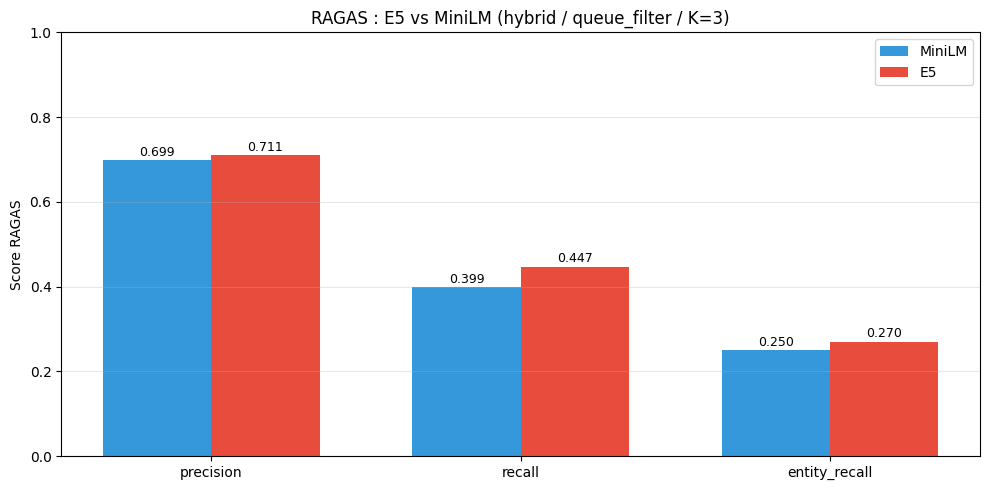


>>> VERDICT RAGAS : E5 (mean_score = 0.4762)
    vs MiniLM (mean_score = 0.4493)


In [24]:
# --- RAGAS : E5 vs MiniLM (hybrid / queue_filter / K=3) ---
# On reutilise les donnees collectees en section 11 pour les 2 modeles
# Config commune : hybrid + queue_filter (meilleure config Hit@1)

from ragas.metrics import ContextPrecision, ContextRecall, ContextEntityRecall
from ragas import EvaluationDataset, evaluate


def make_metrics():
    """Cree des instances fraiches de metriques."""
    return [
        ContextPrecision(llm=evaluator_llm),
        ContextRecall(llm=evaluator_llm),
        ContextEntityRecall(llm=evaluator_llm),
    ]


SCORE_COLS = ["context_precision", "context_recall", "context_entity_recall"]


COMPARE_CONFIGS = {"MiniLM": "tickets", "E5": "tickets_e5"}
COMPARE_FILTER = "queue"
COMPARE_METHOD = "hybrid"

# Re-collecte avec la meilleure config pour chaque modele
print("=== COLLECTE RAGAS : E5 vs MiniLM ===")
print(f"Config : {COMPARE_METHOD} / {COMPARE_FILTER}_filter / K={BEST_K}\n")

ragas_model_data = {}
for model_name, col_name in COMPARE_CONFIGS.items():
    print(f"  Collecte {model_name} ({col_name}) ...")
    ragas_model_data[model_name] = collect_per_case_filter_col(
        test_cases, method=COMPARE_METHOD, limit=BEST_K,
        filter_field=COMPARE_FILTER, collection=col_name
    )

# --- Evaluation RAGAS pour chaque modele ---
print(f"\n=== EVALUATION RAGAS ({len(test_cases)} samples par modele) ===\n")
model_eval_results = {}

for i, (model_name, data) in enumerate(ragas_model_data.items()):
    print(f"[{i+1}/{len(COMPARE_CONFIGS)}] {model_name} ...")
    eval_dataset = EvaluationDataset.from_list(data)

    results = evaluate(
        dataset=eval_dataset,
        metrics=make_metrics(),
        raise_exceptions=False,
        show_progress=True,
        batch_size=1,
    )

    df_res = results.to_pandas()
    model_eval_results[model_name] = df_res

    means = {col: f"{df_res[col].mean():.4f}" for col in SCORE_COLS if col in df_res.columns}
    print(f"  Moyennes : {means}")

    if i < len(COMPARE_CONFIGS) - 1:
        print("  Pause 8s (rate limit) ...")
        time.sleep(8)

# --- Tableau comparatif ---
print("\n=== COMPARAISON RAGAS : E5 vs MiniLM ===\n")
compare_rows = []
for model_name, df_res in model_eval_results.items():
    row = {"model": model_name}
    for col in SCORE_COLS:
        row[col] = df_res[col].mean() if col in df_res.columns else float("nan")
    row["mean_score"] = np.nanmean([row[c] for c in SCORE_COLS])
    compare_rows.append(row)

df_compare = pd.DataFrame(compare_rows)
display(df_compare.style.format({col: "{:.4f}" for col in SCORE_COLS + ["mean_score"]}))

# --- Delta ---
print("\n=== DELTA (E5 - MiniLM) ===")
minilm_row = df_compare[df_compare["model"] == "MiniLM"].iloc[0]
e5_row = df_compare[df_compare["model"] == "E5"].iloc[0]

for col in SCORE_COLS + ["mean_score"]:
    delta = e5_row[col] - minilm_row[col]
    winner = "E5" if delta > 0 else "MiniLM" if delta < 0 else "="
    print(f"  {col:<25} : {delta:+.4f}  ({winner})")

# --- Bar chart comparatif ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SCORE_COLS))
width = 0.35

minilm_scores = [minilm_row[c] for c in SCORE_COLS]
e5_scores = [e5_row[c] for c in SCORE_COLS]

bars1 = ax.bar(x - width/2, minilm_scores, width, label="MiniLM", color="#3498db")
bars2 = ax.bar(x + width/2, e5_scores, width, label="E5", color="#e74c3c")

ax.set_ylabel("Score RAGAS")
ax.set_title(f"RAGAS : E5 vs MiniLM ({COMPARE_METHOD} / {COMPARE_FILTER}_filter / K={BEST_K})")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("context_", "") for c in SCORE_COLS])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Annotations
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- Verdict ---
ragas_winner = "E5" if e5_row["mean_score"] > minilm_row["mean_score"] else "MiniLM"
print(f"\n>>> VERDICT RAGAS : {ragas_winner} (mean_score = {max(e5_row['mean_score'], minilm_row['mean_score']):.4f})")
print(f"    vs {('MiniLM' if ragas_winner == 'E5' else 'E5')} (mean_score = {min(e5_row['mean_score'], minilm_row['mean_score']):.4f})")

## 13. Reranking avec ColBERT

**Principe** : on sur-recupere K=20 resultats avec la meilleure config (E5 / hybrid / queue_filter), puis on reranke avec `answerdotai/answerai-colbert-small-v1` (late-interaction) et on garde les top-3.

**Hypothese** : le reranking ameliore la precision en reordonnant les documents selon une similarite token-a-token plus fine que le cosine dense.

=== COLLECTE AVEC RERANKING ColBERT (server-side) ===
Pipeline : E5 dense + BM25 (K=20) → ColBERT rescore → top-3
Collection : tickets_e5

  60 samples collectes avec reranking

Baseline (hybrid RRF sans reranking) ...
  60 samples collectes sans reranking

=== HIT@1 : RERANKING vs BASELINE ===
  Baseline (E5/hybrid/queue/K=3)      : 0.717
  + ColBERT reranking (prefetch→rescore)  : 0.717
  Delta                                   : +0.000

=== EVALUATION RAGAS : reranking vs baseline ===

  [baseline] ...


Evaluating: 100%|██████████| 180/180 [13:32<00:00,  4.51s/it]


    {'context_precision': '0.7431', 'context_recall': '0.4373', 'context_entity_recall': '0.2719'}
    Pause 8s ...
  [reranked] ...


Evaluating: 100%|██████████| 180/180 [14:38<00:00,  4.88s/it]

    {'context_precision': '0.7861', 'context_recall': '0.3647', 'context_entity_recall': '0.2549'}

=== COMPARAISON RAGAS : RERANKING vs BASELINE ===



,config,context_precision,context_recall,context_entity_recall,mean_score
0,baseline,0.7431,0.4373,0.2719,0.4841
1,reranked,0.7861,0.3647,0.2549,0.4686



=== DELTA (reranked - baseline) ===
  context_precision         : +0.0431  (+)
  context_recall            : -0.0726  (-)
  context_entity_recall     : -0.0170  (-)
  mean_score                : -0.0155  (-)


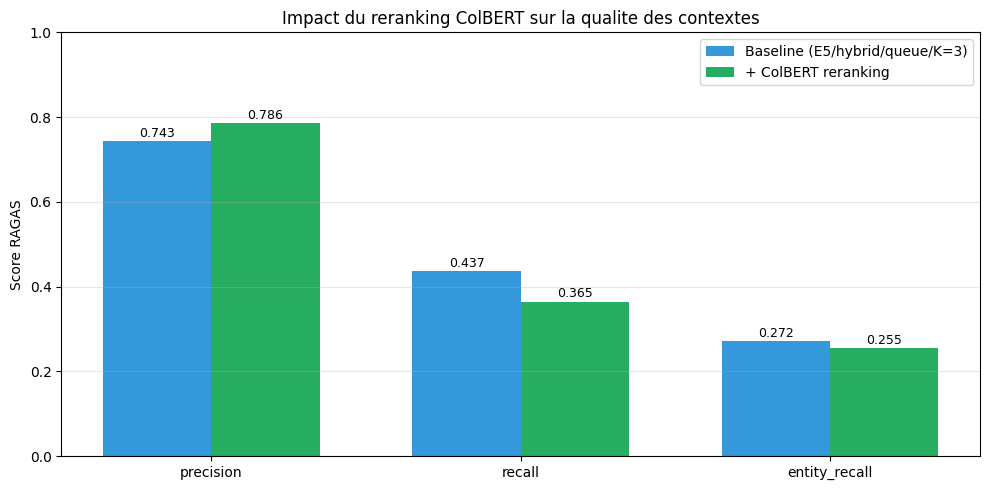


>>> VERDICT : Le reranking ColBERT N AMELIORE PAS les resultats
    Baseline mean_score : 0.4841
    Reranked mean_score : 0.4686
    Delta               : -0.0155


In [26]:
# --- Reranking ColBERT via Qdrant Cloud Inference ---
# Methode : prefetch dense+sparse (K=20) → rescore avec ColBERT (top-3)
# Pas besoin de librairie locale, tout est cote serveur Qdrant

RERANK_COLLECTION = "tickets_e5"  # doit avoir le vecteur colbert (re-ingestion necessaire)
FINAL_K = 3

def collect_with_reranking(test_cases, limit, filter_field, collection):
    """Collecte avec hybrid_rerank (ColBERT server-side)."""
    dataset = []
    for tc in test_cases:
        filter_value = tc.get(filter_field, None)
        kwargs = {filter_field if filter_field != "type" else "type_": filter_value}
        results = search(tc["query"], method="hybrid_rerank", limit=limit, collection=collection, **kwargs)
        contexts = [r["body"] for r in results] if results else []
        response = results[0]["answer"] if results else ""
        dataset.append({
            "user_input": tc["query"],
            "retrieved_contexts": contexts,
            "response": response,
            "reference": tc["reference"],
        })
    return dataset


# --- Collecte avec reranking ColBERT ---
print("=== COLLECTE AVEC RERANKING ColBERT (server-side) ===")
print(f"Pipeline : E5 dense + BM25 (K=20) → ColBERT rescore → top-{FINAL_K}")
print(f"Collection : {RERANK_COLLECTION}\n")

reranked_data = collect_with_reranking(
    test_cases, limit=FINAL_K, filter_field="queue", collection=RERANK_COLLECTION
)
print(f"  {len(reranked_data)} samples collectes avec reranking")

# --- Collecte SANS reranking (baseline = E5 hybrid RRF) ---
print("\nBaseline (hybrid RRF sans reranking) ...")
baseline_data = collect_per_case_filter_col(
    test_cases, method="hybrid", limit=FINAL_K,
    filter_field="queue", collection=RERANK_COLLECTION
)
print(f"  {len(baseline_data)} samples collectes sans reranking")

# --- Hit@1 comparison ---
hit1_reranked = hit_at_k(reranked_data, k=1)
hit1_baseline = hit_at_k(baseline_data, k=1)
print(f"\n=== HIT@1 : RERANKING vs BASELINE ===")
print(f"  Baseline (E5/hybrid/queue/K={FINAL_K})      : {hit1_baseline:.3f}")
print(f"  + ColBERT reranking (prefetch→rescore)  : {hit1_reranked:.3f}")
print(f"  Delta                                   : {hit1_reranked - hit1_baseline:+.3f}")

# --- RAGAS comparison ---
print(f"\n=== EVALUATION RAGAS : reranking vs baseline ===\n")

rerank_eval_results = {}
for label, data in [("baseline", baseline_data), ("reranked", reranked_data)]:
    print(f"  [{label}] ...")
    eval_dataset = EvaluationDataset.from_list(data)
    results = evaluate(
        dataset=eval_dataset,
        metrics=make_metrics(),
        raise_exceptions=False,
        show_progress=True,
        batch_size=1,
    )
    rerank_eval_results[label] = results.to_pandas()
    means = {col: f"{rerank_eval_results[label][col].mean():.4f}" for col in SCORE_COLS}
    print(f"    {means}")
    if label == "baseline":
        print("    Pause 8s ...")
        time.sleep(8)

# --- Tableau comparatif ---
print("\n=== COMPARAISON RAGAS : RERANKING vs BASELINE ===\n")
rerank_rows = []
for label, df_res in rerank_eval_results.items():
    row = {"config": label}
    for col in SCORE_COLS:
        row[col] = df_res[col].mean()
    row["mean_score"] = np.nanmean([row[c] for c in SCORE_COLS])
    rerank_rows.append(row)

df_rerank = pd.DataFrame(rerank_rows)
display(df_rerank.style.format({col: "{:.4f}" for col in SCORE_COLS + ["mean_score"]}))

# --- Delta ---
base_row = df_rerank[df_rerank["config"] == "baseline"].iloc[0]
rank_row = df_rerank[df_rerank["config"] == "reranked"].iloc[0]

print("\n=== DELTA (reranked - baseline) ===")
for col in SCORE_COLS + ["mean_score"]:
    delta = rank_row[col] - base_row[col]
    direction = "+" if delta > 0 else "-" if delta < 0 else "="
    print(f"  {col:<25} : {delta:+.4f}  ({direction})")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SCORE_COLS))
width = 0.35

b_scores = [base_row[c] for c in SCORE_COLS]
r_scores = [rank_row[c] for c in SCORE_COLS]

bars1 = ax.bar(x - width/2, b_scores, width, label="Baseline (E5/hybrid/queue/K=3)", color="#3498db")
bars2 = ax.bar(x + width/2, r_scores, width, label="+ ColBERT reranking", color="#27ae60")

ax.set_ylabel("Score RAGAS")
ax.set_title("Impact du reranking ColBERT sur la qualite des contextes")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("context_", "") for c in SCORE_COLS])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- Verdict ---
rerank_better = rank_row["mean_score"] > base_row["mean_score"]
print(f"\n>>> VERDICT : Le reranking ColBERT {'AMELIORE' if rerank_better else 'N AMELIORE PAS'} les resultats")
print(f"    Baseline mean_score : {base_row['mean_score']:.4f}")
print(f"    Reranked mean_score : {rank_row['mean_score']:.4f}")
print(f"    Delta               : {rank_row['mean_score'] - base_row['mean_score']:+.4f}")

## 14. Robustesse du juge LLM : comparaison de 3 juges

On re-evalue la **meilleure config** (E5 / hybrid / queue_filter / K=3) avec 3 juges LLM differents pour verifier la stabilite des scores RAGAS.

| Juge | Modele OpenRouter | Type |
|------|-------------------|------|
| Gemini Flash | `google/gemini-2.0-flash-001` | rapide, bon marche |
| Llama 3.3 70B | `meta-llama/llama-3.3-70b-instruct` | open-source, performant |
| GPT-5 Nano | `openai/gpt-5-nano` | compact, frontier |

**Critere** : si les 3 juges donnent des scores correles (Pearson > 0.5) → les resultats sont robustes.

In [5]:
# --- Evaluation avec 3 juges LLM ---
# Ce cell ne fait QUE le calcul (pas de visualisation)

BEST_K = 3  # identifie en section 5b

JUDGES = {
    "Gemini Flash": "google/gemini-2.0-flash-001",
    "Llama 3.3 70B": "meta-llama/llama-3.3-70b-instruct",
    "GPT-5 Nano": "openai/gpt-5-nano",
}

# Creation des LLM instances
judge_llms = {}
for name, model_id in JUDGES.items():
    judge_llms[name] = llm_factory(model_id, client=client)
    print(f"  Juge configure : {name} ({model_id})")

# Collecte des donnees (meilleure config : E5/hybrid/queue/K=3)
print(f"\n=== COLLECTE : E5 / hybrid / queue_filter / K={BEST_K} ===")
judge_data = collect_per_case_filter_col(
    test_cases, method="hybrid", limit=BEST_K,
    filter_field="queue", collection="tickets_e5"
)
print(f"  {len(judge_data)} samples collectes")

# Evaluation avec chaque juge
eval_dataset = EvaluationDataset.from_list(judge_data)

judge_eval_results = {}
for i, (name, llm_instance) in enumerate(judge_llms.items()):
    print(f"\n[{i+1}/{len(JUDGES)}] Evaluation avec {name} ...")

    metrics = [
        ContextPrecision(llm=llm_instance),
        ContextRecall(llm=llm_instance),
        ContextEntityRecall(llm=llm_instance),
    ]

    results = evaluate(
        dataset=eval_dataset,
        metrics=metrics,
        raise_exceptions=False,
        show_progress=True,
        batch_size=1,
    )

    df_res = results.to_pandas()
    judge_eval_results[name] = df_res

    means = {col: f"{df_res[col].mean():.4f}" for col in SCORE_COLS if col in df_res.columns}
    print(f"  {name} : {means}")

    if i < len(JUDGES) - 1:
        print("  Pause 10s (rate limit) ...")
        time.sleep(10)

print("\n=== EVALUATIONS TERMINEES ===")

  Juge configure : Gemini Flash (google/gemini-2.0-flash-001)
  Juge configure : Llama 3.3 70B (meta-llama/llama-3.3-70b-instruct)
  Juge configure : GPT-5 Nano (openai/gpt-5-nano)

=== COLLECTE : E5 / hybrid / queue_filter / K=3 ===


NameError: name 'collect_per_case_filter_col' is not defined

In [ ]:
# --- Analyse : tableaux et correlations (pas de graphiques) ---
from scipy.stats import pearsonr, spearmanr

# Tableau comparatif des moyennes par juge
print("=== SCORES MOYENS PAR JUGE ===\n")
judge_summary_rows = []
for name, df_res in judge_eval_results.items():
    row = {"judge": name}
    for col in SCORE_COLS:
        row[col] = df_res[col].mean() if col in df_res.columns else float("nan")
    row["mean_score"] = np.nanmean([row[c] for c in SCORE_COLS])
    judge_summary_rows.append(row)

df_judge_summary = pd.DataFrame(judge_summary_rows)
display(df_judge_summary.style.format({col: "{:.4f}" for col in SCORE_COLS + ["mean_score"]}))

# Correlation entre chaque paire de juges
print("\n=== CORRELATIONS ENTRE JUGES (par sample) ===\n")
judge_names = list(judge_eval_results.keys())
correlation_rows = []

for i in range(len(judge_names)):
    for j in range(i + 1, len(judge_names)):
        name_a, name_b = judge_names[i], judge_names[j]
        df_a, df_b = judge_eval_results[name_a], judge_eval_results[name_b]
        print(f"  {name_a} vs {name_b} :")

        for col in SCORE_COLS:
            scores_a = df_a[col].dropna()
            scores_b = df_b[col].dropna()
            common_idx = scores_a.index.intersection(scores_b.index)

            if len(common_idx) > 5:
                r_p, p_p = pearsonr(scores_a[common_idx], scores_b[common_idx])
                r_s, p_s = spearmanr(scores_a[common_idx], scores_b[common_idx])
                print(f"    {col:<25} : Pearson={r_p:.3f} (p={p_p:.3f})  Spearman={r_s:.3f}")
                correlation_rows.append({
                    "pair": f"{name_a} vs {name_b}",
                    "metric": col,
                    "pearson": r_p,
                    "pearson_p": p_p,
                    "spearman": r_s,
                })
            else:
                print(f"    {col:<25} : pas assez de donnees")
        print()

df_correlations = pd.DataFrame(correlation_rows)

# Verdict robustesse
print("=== VERDICT ROBUSTESSE ===\n")
if len(df_correlations) > 0:
    avg_pearson = df_correlations["pearson"].mean()
    print(f"  Pearson moyen (toutes paires, toutes metriques) : {avg_pearson:.3f}")
    if avg_pearson > 0.7:
        print("  → FORTE coherence entre juges : resultats robustes")
    elif avg_pearson > 0.5:
        print("  → COHERENCE MODEREE : tendances fiables, scores absolus variables")
    elif avg_pearson > 0.3:
        print("  → COHERENCE FAIBLE : rankings relatifs probablement stables")
    else:
        print("  → PAS DE COHERENCE : les scores dependent fortement du juge choisi")
else:
    print("  Pas assez de donnees pour calculer les correlations")

In [ ]:
# --- Visualisation : bar chart comparaison des 3 juges ---
# (Modifier ce cell pour changer titres/couleurs sans relancer les calculs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Bar chart : scores moyens par juge ---
ax = axes[0]
judge_names_plot = df_judge_summary["judge"].tolist()
x = np.arange(len(SCORE_COLS))
width = 0.25
colors = ["#f39c12", "#3498db", "#2ecc71"]

for i, (_, row) in enumerate(df_judge_summary.iterrows()):
    scores = [row[c] for c in SCORE_COLS]
    bars = ax.bar(x + i * width - width, scores, width,
                  label=row["judge"], color=colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

ax.set_ylabel("Score RAGAS")
ax.set_title("Scores par metrique et par juge")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("context_", "") for c in SCORE_COLS])
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# --- Bar chart : mean_score par juge ---
ax2 = axes[1]
mean_scores = df_judge_summary["mean_score"].tolist()
bars = ax2.bar(judge_names_plot, mean_scores, color=colors, edgecolor="black", linewidth=0.5)

for bar in bars:
    h = bar.get_height()
    ax2.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10, fontweight="bold")

ax2.set_ylabel("Mean Score")
ax2.set_title("Score moyen global par juge")
ax2.set_ylim(0, 1)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- Heatmap correlations (si disponible) ---
if len(df_correlations) > 0:
    fig2, ax3 = plt.subplots(figsize=(8, 4))
    pivot_corr = df_correlations.pivot(index="pair", columns="metric", values="pearson")
    sns.heatmap(pivot_corr, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1,
                ax=ax3, linewidths=0.5)
    ax3.set_title("Correlation Pearson entre juges (par metrique)")
    plt.tight_layout()
    plt.show()